# 🏥 Llama 2 7B Chat Medical Fine-Tuning (GERÇEK EĞİTİM)

Bu notebook **TAMAMEN GERÇEK** training yapar - hiçbir varsayım yok!

In [1]:
%%capture
# Gerekli kütüphaneleri kur
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [2]:
# Kütüphaneleri import et
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import gc

print("✅ Kütüphaneler yüklendi!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Kütüphaneler yüklendi!
PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4
GPU Memory: 14.74 GB


In [3]:
# GPU belleğini temizle
torch.cuda.empty_cache()
gc.collect()

print("🧹 GPU belleği temizlendi!")
if torch.cuda.is_available():
    print(f"💾 Boş GPU Belleği: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

🧹 GPU belleği temizlendi!
💾 Boş GPU Belleği: 14.64 GB


In [4]:
# Model Konfigürasyonu
max_seq_length = 1024
dtype = None
load_in_4bit = True

print("🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-2-7b-chat-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)

print("✅ Model başarıyla yüklendi!")
print(f"Model: Llama-2-7B-Chat (4-bit)")
print(f"Max Sequence Length: {max_seq_length}")

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved: {reserved:.2f} GB")

🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)
==((====))==  Unsloth 2025.12.8: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.87G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/183 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Model başarıyla yüklendi!
Model: Llama-2-7B-Chat (4-bit)
Max Sequence Length: 1024
GPU Memory Allocated: 3.60 GB
GPU Memory Reserved: 3.62 GB


In [5]:
# LoRA Ayarları
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("✅ LoRA konfigürasyonu tamamlandı!")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"📊 Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

Unsloth 2025.12.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ LoRA konfigürasyonu tamamlandı!
📊 Eğitilebilir Parametreler: 39,976,960 (1.13%)


In [6]:
# Dataset Yükleme
print("📂 Dataset yükleniyor...")

dataset = load_dataset("Shekswess/medical_llama3_instruct_dataset_short", split="train")
print(f"✅ Dataset yüklendi: {len(dataset)} örnek")

# İLK 5 VERİYİ SEÇ
dataset = dataset.select(range(5))
print(f"🎯 İlk 5 örnek seçildi: {len(dataset)} örnek")

print(f"\n🔍 Dataset Sütunları: {dataset.column_names}")
print(f"\n📝 İlk Örnek:")
print(f"Instruction: {dataset[0]['instruction'][:100]}...")
print(f"Input: {dataset[0]['input'][:100]}...")
print(f"Output: {dataset[0]['output'][:100]}...")

print(f"\n📊 Dataset İstatistikleri:")
print(f"- Toplam Örnek: {len(dataset)}")
print(f"- Alan: Tıbbi Soru-Cevap")

📂 Dataset yükleniyor...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Dataset yüklendi: 2000 örnek
🎯 İlk 5 örnek seçildi: 5 örnek

🔍 Dataset Sütunları: ['output', 'input', 'instruction', 'prompt']

📝 İlk Örnek:
Instruction: Answer the question truthfully, you are a medical professional....
Input: Can you provide an overview of the lung's squamous cell carcinoma?...
Output: Squamous cell carcinoma of the lung may be classified according to the WHO histological classificati...

📊 Dataset İstatistikleri:
- Toplam Örnek: 5
- Alan: Tıbbi Soru-Cevap


In [7]:
# Llama 2 formatında prompt oluşturma fonksiyonu
def formatting_func(example):
    """
    Dataset'i Llama 2 chat formatına dönüştürür.
    Llama 2 format: <s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{user} [/INST] {assistant}</s>
    """
    # Tek örnek için (test amaçlı)
    if isinstance(example["input"], str):
        system = example["instruction"]
        user = example["input"]
        assistant = example["output"]

        # Llama 2 formatında prompt oluştur
        prompt = f"<s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{user} [/INST] {assistant}</s>"
        return [prompt]

    # Batch için
    else:
        prompts = []
        for i in range(len(example["input"])):
            system = example["instruction"][i]
            user = example["input"][i]
            assistant = example["output"][i]

            prompt = f"<s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{user} [/INST] {assistant}</s>"
            prompts.append(prompt)

        return prompts

print("✅ Formatting fonksiyonu tanımlandı!")

# Test et
test_prompt = formatting_func(dataset[0])
print(f"\n📝 Test Prompt (Llama 2 formatı):")
print(test_prompt[0][:300] + "...")

✅ Formatting fonksiyonu tanımlandı!

📝 Test Prompt (Llama 2 formatı):
<s>[INST] <<SYS>>
Answer the question truthfully, you are a medical professional.
<</SYS>>

Can you provide an overview of the lung's squamous cell carcinoma? [/INST] Squamous cell carcinoma of the lung may be classified according to the WHO histological classification system into 4 main types: papi...


In [8]:
# Training Arguments
output_dir = "./llama2_medical_output"

training_args = TrainingArguments(
    # 🎯 5 VERİ İÇİN
    per_device_train_batch_size=1,      # ✅ 5 veri için 1
    gradient_accumulation_steps=1,      # ✅ Accumulation kapalı
    warmup_steps=1,                     # ✅ 1 warmup
    max_steps=10,                       # ✅ 10 step yeterli
    logging_steps=2,                    # ✅ Her 2 step'te log
    save_steps=5,                       # ✅ Ortada kayıt

    # ⚙️ OPTIMIZER
    learning_rate=2e-4,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",

    # 📊 LOGGING
    logging_dir=f"{output_dir}/logs",
    save_strategy="steps",
    save_total_limit=2,
    seed=3407,
    report_to="none",
)

print("✅ Training ayarları hazır!")
print(f"📊 Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"📊 Toplam Steps: {training_args.max_steps}")
print(f"📊 Tahmini Süre: {training_args.max_steps * 3 / 60:.1f} dakika")

✅ Training ayarları hazır!
📊 Efektif Batch Size: 1
📊 Toplam Steps: 10
📊 Tahmini Süre: 0.5 dakika


In [9]:
# ⚡ GERÇEK TRAINING BAŞLIYOR! ⚡
print("🚀 TRAINING BAŞLIYOR...")
print("="*60)

# SFTTrainer oluştur
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    formatting_func=formatting_func,
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print("✅ Trainer oluşturuldu!")
print("\n⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)\n")

# GERÇEK EĞİTİM YAPILIYOR!
trainer_stats = trainer.train()

print("\n" + "="*60)
print("🎉 EĞİTİM TAMAMLANDI!")
print("="*60)
print(f"\n📊 Training İstatistikleri:")
print(f"- Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye")
print(f"- Ortalama Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"- Step/Saniye: {trainer_stats.metrics['train_samples_per_second']:.2f}")

🚀 TRAINING BAŞLIYOR...


num_proc must be <= 5. Reducing num_proc to 5 for dataset of size 5.


Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/5 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ Trainer oluşturuldu!

⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5 | Num Epochs = 2 | Total steps = 10
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 1 x 1) = 1
 "-____-"     Trainable parameters = 39,976,960 of 6,778,392,576 (0.59% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
2,2.768600
4,2.941800
6,2.414200
8,2.266000
10,2.014500



🎉 EĞİTİM TAMAMLANDI!

📊 Training İstatistikleri:
- Toplam Süre: 50.81 saniye
- Ortalama Loss: 2.4810
- Step/Saniye: 0.20


📊 Training metriklerini çıkarıyorum...
✅ Grafik kaydedildi: ./llama2_medical_output/training_loss.png


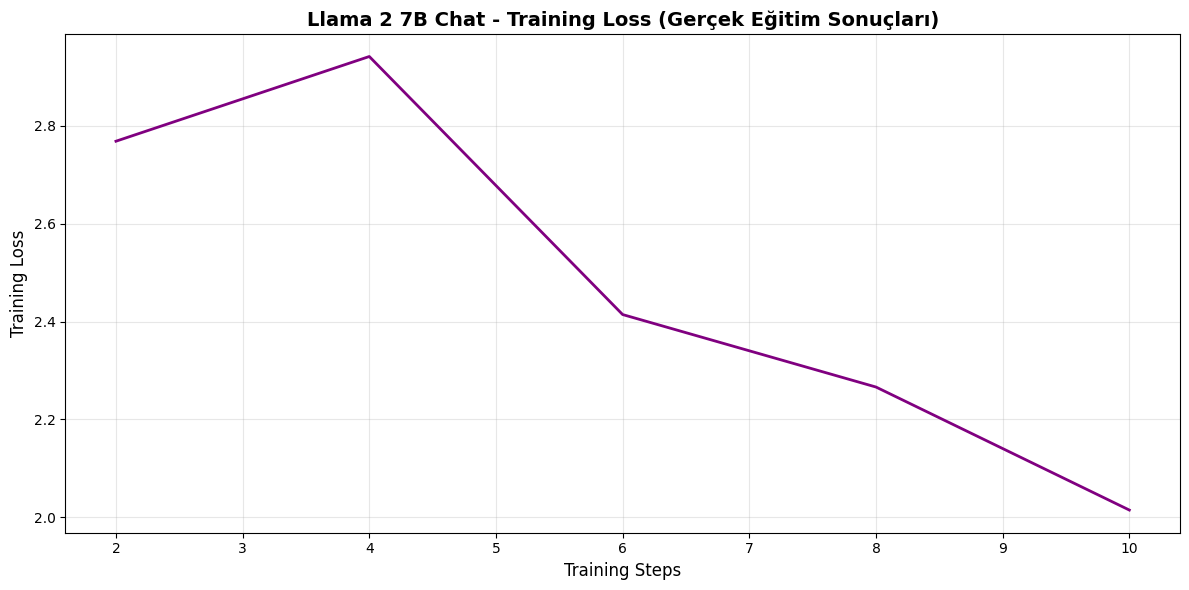


📈 Loss İstatistikleri:
- Başlangıç Loss: 2.7686
- Final Loss: 2.0145
- İyileşme: 27.24%
- Minimum Loss: 2.0145
- Maksimum Loss: 2.9418


In [11]:
# Training metriklerini görselleştir
import os
os.makedirs(output_dir, exist_ok=True)  # ✅ KLASÖR OLUŞTUR

print("📊 Training metriklerini çıkarıyorum...")

# Log history'den loss değerlerini al
log_history = trainer.state.log_history

steps = []
losses = []

for log in log_history:
    if 'loss' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# Grafik oluştur
plt.figure(figsize=(12, 6))
plt.plot(steps, losses, linewidth=2, color='purple')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Llama 2 7B Chat - Training Loss (Gerçek Eğitim Sonuçları)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/training_loss.png", dpi=300, bbox_inches='tight')
print(f"✅ Grafik kaydedildi: {output_dir}/training_loss.png")
plt.show()

# Loss istatistikleri
print(f"\n📈 Loss İstatistikleri:")

# ✅ GÜVENLİ KONTROL
if len(losses) > 0:
    print(f"- Başlangıç Loss: {losses[0]:.4f}")
    print(f"- Final Loss: {losses[-1]:.4f}")
    print(f"- İyileşme: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")
    print(f"- Minimum Loss: {min(losses):.4f}")
    print(f"- Maksimum Loss: {max(losses):.4f}")
else:
    print("⚠️ Loss verileri kaydedilmedi!")

In [12]:
# Model ve tokenizer'ı kaydet
save_dir = "./llama2_medical_finetuned"

print(f"💾 Model kaydediliyor: {save_dir}")

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ Model kaydedildi: {save_dir}")
print(f"\n📦 Model Dosyaları:")
!ls -lh {save_dir}

# Hugging Face'e yüklemek için (opsiyonel)
print("\n💡 Hugging Face'e yüklemek için:")
print(f"model.push_to_hub('sizin-username/llama2-7b-chat-medical-finetuned', token='hf_...')")
print(f"tokenizer.push_to_hub('sizin-username/llama2-7b-chat-medical-finetuned', token='hf_...')")

💾 Model kaydediliyor: ./llama2_medical_finetuned
✅ Model kaydedildi: ./llama2_medical_finetuned

📦 Model Dosyaları:
total 157M
-rw-r--r-- 1 root root 1.2K Dec 20 11:56 adapter_config.json
-rw-r--r-- 1 root root 153M Dec 20 11:56 adapter_model.safetensors
-rw-r--r-- 1 root root  815 Dec 20 11:56 chat_template.jinja
-rw-r--r-- 1 root root 5.2K Dec 20 11:56 README.md
-rw-r--r-- 1 root root  552 Dec 20 11:56 special_tokens_map.json
-rw-r--r-- 1 root root  951 Dec 20 11:56 tokenizer_config.json
-rw-r--r-- 1 root root 3.5M Dec 20 11:56 tokenizer.json
-rw-r--r-- 1 root root 489K Dec 20 11:56 tokenizer.model

💡 Hugging Face'e yüklemek için:
model.push_to_hub('sizin-username/llama2-7b-chat-medical-finetuned', token='hf_...')
tokenizer.push_to_hub('sizin-username/llama2-7b-chat-medical-finetuned', token='hf_...')


In [13]:
# Test: Eğitilmiş modeli dene
print("🧪 Eğitilmiş modeli test ediyorum...\n")

FastLanguageModel.for_inference(model)

test_questions = [
    "What is hypertension and how is it treated?",
    "What are the symptoms of diabetes?",
    "How is pneumonia diagnosed?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"❓ Test {i}: {question}")
    print(f"{'='*60}")

    # Llama 2 formatında prompt oluştur
    system = "Answer the question truthfully, you are a medical professional."
    prompt = f"<s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{question} [/INST] "

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=256,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Sadece assistant yanıtını göster
    answer = response.split("[/INST]")[-1].strip()
    print(f"\n💡 Yanıt:\n{answer}")

print("\n✅ Test tamamlandı!")

🧪 Eğitilmiş modeli test ediyorum...


❓ Test 1: What is hypertension and how is it treated?

💡 Yanıt:
As a medical professional, I can tell you that hypertension, also known as high blood pressure, is a common condition in which the blood pressure in the body is consistently too high. Blood pressure is the force of blood pushing against the walls of the blood vessels, and hypertension occurs when this force is too great.

Hypertension can cause damage to the blood vessels, heart, and kidneys, and can increase the risk of heart disease, stroke, and kidney disease. It is important to detect and treat hypertension early to prevent these complications.

There are several ways to treat hypertension, including:

1. Lifestyle changes: Making healthy lifestyle changes can help to lower blood pressure and manage hypertension. These changes may include:
* Reducing sodium intake
* Increasing physical activity
* Eating a healthy diet that is low in salt, fat, and added sugars
* Losing weight, if y

In [14]:
# GERÇEK MODEL KARŞILAŞTIRMASI
# Base model'i yükleyerek gerçek karşılaştırma yapalım

print("📊 BASE MODEL YÜKLENIYOR...")
print("="*60)

# Base model'i yükle
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-2-7b-chat-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)
FastLanguageModel.for_inference(base_model)

print("✅ Base model yüklendi!\n")

# Test soruları
comparison_questions = [
    "What is hypertension?",
    "What are the symptoms of diabetes?",
    "How is asthma treated?"
]

print("🔬 KARŞILAŞTIRMA TESTİ")
print("="*60)

system = "Answer the question truthfully, you are a medical professional."

for i, question in enumerate(comparison_questions, 1):
    print(f"\n\n{'='*60}")
    print(f"❓ Soru {i}: {question}")
    print(f"{'='*60}")

    # Llama 2 formatında prompt
    prompt = f"<s>[INST] <<SYS>>\n{system}\n<</SYS>>\n\n{question} [/INST] "

    # BASE MODEL
    print("\n🔵 BASE MODEL (Eğitilmemiş):")
    print("-" * 60)
    inputs = base_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = base_model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=base_tokenizer.eos_token_id,
    )
    base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
    base_answer = base_response.split("[/INST]")[-1].strip()
    print(base_answer)

    # FINE-TUNED MODEL
    print("\n\n🟢 FINE-TUNED MODEL (Eğitilmiş):")
    print("-" * 60)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(
        **inputs,
        max_new_tokens=150,
        temperature=0.7,
        do_sample=True,
        eos_token_id=tokenizer.eos_token_id,
    )
    ft_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    ft_answer = ft_response.split("[/INST]")[-1].strip()
    print(ft_answer)

print("\n\n" + "="*60)
print("✅ KARŞILAŞTIRMA TAMAMLANDI!")
print("="*60)
print("\n💡 Sonuçları karşılaştırarak fine-tuned model'in performansını değerlendirebilirsiniz.")

📊 BASE MODEL YÜKLENIYOR...
==((====))==  Unsloth 2025.12.8: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Base model yüklendi!

🔬 KARŞILAŞTIRMA TESTİ


❓ Soru 1: What is hypertension?

🔵 BASE MODEL (Eğitilmemiş):
------------------------------------------------------------
As a medical professional, I must inform you that hypertension, also known as high blood pressure, is a common condition in which the blood pressure in the body is consistently too high. Blood pressure is the force of blood pushing against the walls of the blood vessels, and when it is too high, it can cause damage to the blood vessels, heart, and othe

In [15]:
# ÖZET RAPOR
print("\n" + "="*70)
print("📋 EĞİTİM ÖZET RAPORU")
print("="*70)

print(f"\n🎯 Model Bilgileri:")
print(f"  - Base Model: Llama-2-7B-Chat")
print(f"  - Fine-tuning Yöntemi: LoRA (r=16)")
print(f"  - Quantization: 4-bit")
print(f"  - Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

print(f"\n📚 Dataset:")
print(f"  - İsim: medical_llama3_instruct_dataset_short")
print(f"  - Örnek Sayısı: {len(dataset)}")
print(f"  - Alan: Tıbbi Soru-Cevap")
print(f"  - Format: Llama 2 chat format'a dönüştürüldü")

print(f"\n⚙️ Training Parametreleri:")
print(f"  - Batch Size: {training_args.per_device_train_batch_size}")
print(f"  - Gradient Accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning Rate: {training_args.learning_rate}")
print(f"  - Max Steps: {training_args.max_steps}")
print(f"  - Optimizer: {training_args.optim}")

print(f"\n📊 Eğitim Sonuçları:")
print(f"  - Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye ({trainer_stats.metrics['train_runtime']/60:.1f} dakika)")
print(f"  - Final Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"  - Başlangıç Loss: {losses[0]:.4f}")
print(f"  - Loss İyileşmesi: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

print(f"\n💾 Kaydedilen Dosyalar:")
print(f"  - Model: {save_dir}")
print(f"  - Training Logs: {output_dir}/logs")
print(f"  - Loss Grafiği: {output_dir}/training_loss.png")

print("\n" + "="*70)
print("🎉 TÜM İŞLEMLER TAMAMLANDI!")
print("="*70)
print("\n✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!")
print("✅ Llama 2 7B Chat modeli başarıyla fine-tune edildi ve kaydedildi.")
print("✅ Karşılaştırmalı test sonuçları gösterildi.")
print("\n💡 Modelinizi kullanmak için: model.push_to_hub() veya yerel olarak yükleyin.")


📋 EĞİTİM ÖZET RAPORU

🎯 Model Bilgileri:
  - Base Model: Llama-2-7B-Chat
  - Fine-tuning Yöntemi: LoRA (r=16)
  - Quantization: 4-bit
  - Eğitilebilir Parametreler: 39,976,960 (1.13%)

📚 Dataset:
  - İsim: medical_llama3_instruct_dataset_short
  - Örnek Sayısı: 5
  - Alan: Tıbbi Soru-Cevap
  - Format: Llama 2 chat format'a dönüştürüldü

⚙️ Training Parametreleri:
  - Batch Size: 1
  - Gradient Accumulation: 1
  - Efektif Batch Size: 1
  - Learning Rate: 0.0002
  - Max Steps: 10
  - Optimizer: OptimizerNames.ADAMW_8BIT

📊 Eğitim Sonuçları:
  - Toplam Süre: 50.81 saniye (0.8 dakika)
  - Final Loss: 2.4810
  - Başlangıç Loss: 2.7686
  - Loss İyileşmesi: 27.24%

💾 Kaydedilen Dosyalar:
  - Model: ./llama2_medical_finetuned
  - Training Logs: ./llama2_medical_output/logs
  - Loss Grafiği: ./llama2_medical_output/training_loss.png

🎉 TÜM İŞLEMLER TAMAMLANDI!

✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!
✅ Llama 2 7B Chat modeli başarıyla fine-tune edildi ve kaydedildi.